In [90]:
# =========================
# IMPORTS GENERALES
# IMPORT GENERALI
# =========================

# pandas y numpy se utilizan para trabajar con datos tabulares
# y realizar operaciones numéricas de forma eficiente.
# pandas e numpy si usano per lavorare con dati tabellari
# e per eseguire operazioni numeriche in modo efficiente.
import pandas as pd
import numpy as np

# matplotlib y seaborn se utilizan para crear gráficas y visualizaciones
# que ayuden a interpretar mejor el comportamiento de los datos.
# matplotlib e seaborn si usano per creare grafici e visualizzazioni
# che aiutano a interpretare meglio il comportamento dei dati.
import matplotlib.pyplot as plt
import seaborn as sns

# SQLAlchemy se utiliza para conectar el notebook con PostgreSQL
# y cargar directamente las tablas de la base de datos.
# SQLAlchemy si usa per collegare il notebook a PostgreSQL
# e caricare direttamente le tabelle del database.
from sqlalchemy import create_engine

# Herramientas de scikit-learn para entrenar y evaluar modelos
# de detección de anomalías.
# Strumenti di scikit-learn per addestrare e valutare modelli
# di rilevamento anomalie.
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# os y sys permiten trabajar con rutas del sistema y añadir carpetas
# al path de Python si fuese necesario.
# os e sys permettono di lavorare con i percorsi del sistema e aggiungere cartelle
# al path di Python se necessario.
import os
import sys

# warnings se utiliza para ocultar avisos no críticos y mantener
# la salida del notebook más limpia.
# warnings si usa per nascondere avvisi non critici e mantenere
# l'output del notebook più pulito.
import warnings
warnings.filterwarnings("ignore")

# Configuración visual de pandas para mostrar más columnas y filas
# cuando inspeccionamos los DataFrames.
# Configurazione visiva di pandas per mostrare più colonne e righe
# quando ispezioniamo i DataFrame.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Configuración estética general de seaborn para que las gráficas
# tengan un formato más claro y profesional.
# Configurazione estetica generale di seaborn affinché i grafici
# abbiano un aspetto più chiaro e professionale.
sns.set_theme(style="whitegrid")

# PoC - Detección de anomalías de comportamiento en Login Log y Activity Log

## Objetivo
Construir un sistema de Machine Learning basado en Árboles de Decisión que sea capaz de detectar comportamientos anómalos en el uso de una aplicación tipo gestor de contraseñas.

## Reglas de negocio definidas

### 1. Login Log
- Los usuarios trabajan de lunes a viernes entre las 09:00 y las 18:00.
- Usuario 1 (**Matteo Nicolosi**): logins habituales entre 09:00 y 12:00.
- Usuario 2 (**Diego Scardino**): logins habituales entre 12:00 y 15:00.
- Usuario 3 (**Emilio Sardo**): logins habituales entre 15:00 y 18:00.

### 2. Activity Log
- Las acciones válidas se realizan de lunes a viernes entre las 09:00 y las 18:00.
- Solo se consideran normales acciones sobre `entity_id = 1` (**password**) dentro de los elementos asignados a cada usuario.
- Acciones disponibles:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Objetivos del modelo
- Detectar logins fuera de la franja habitual del usuario.
- Detectar acciones sobre elementos no autorizados para ese usuario.
- Detectar acciones fuera del horario laboral o en días no laborables.

---

# PoC - Rilevamento di anomalie comportamentali nei Login Log e negli Activity Log

## Obiettivo
Costruire un sistema di Machine Learning basato su Alberi di Decisione capace di rilevare comportamenti anomali nell’utilizzo di un’applicazione simile a un gestore di password.

## Regole di business definite

### 1. Login Log
- Gli utenti lavorano dal lunedì al venerdì tra le 09:00 e le 18:00.
- Utente 1 (**Matteo Nicolosi**): login abituali tra le 09:00 e le 12:00.
- Utente 2 (**Diego Scardino**): login abituali tra le 12:00 e le 15:00.
- Utente 3 (**Emilio Sardo**): login abituali tra le 15:00 e le 18:00.

### 2. Activity Log
- Le azioni valide vengono eseguite dal lunedì al venerdì tra le 09:00 e le 18:00.
- Sono considerate normali solo le azioni su `entity_id = 1` (**password**) all’interno degli elementi assegnati a ciascun utente.
- Azioni disponibili:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Obiettivi del modello
- Rilevare login effettuati fuori dalla fascia oraria abituale dell’utente.
- Rilevare azioni su elementi non autorizzati per quello specifico utente.
- Rilevare azioni eseguite fuori dall’orario lavorativo o in giorni non lavorativi.

In [91]:
# =========================
# CONEXIÓN A POSTGRESQL
# CONNESSIONE A POSTGRESQL
# =========================

# Definimos la configuración de conexión con la base de datos PostgreSQL.
# Qui si indican el host, el puerto, el nombre de la base de datos,
# el usuario y la contraseña.
# Definiamo la configurazione di connessione al database PostgreSQL.
# Qui si indicano host, porta, nome del database,
# utente e password.
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "dbname": "Audit",
    "user": "dani",
    "password": ""
}

# Construimos la URL de conexión en formato compatible con SQLAlchemy.
# Esta URL será utilizada por create_engine para abrir la conexión
# entre el notebook y PostgreSQL.
# Costruiamo l'URL di connessione in formato compatibile con SQLAlchemy.
# Questo URL verrà utilizzato da create_engine per aprire la connessione
# tra il notebook e PostgreSQL.
connection_url = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
)

# Creamos el motor de conexión con SQLAlchemy.
# A partir de este objeto podremos cargar tablas SQL directamente
# en DataFrames de pandas mediante consultas.
# Creiamo il motore di connessione con SQLAlchemy.
# A partire da questo oggetto potremo caricare tabelle SQL direttamente
# in DataFrame di pandas tramite query.
engine = create_engine(connection_url)

# Mensaje de confirmación para comprobar que la configuración se ha ejecutado.
# Messaggio di conferma per verificare che la configurazione sia stata eseguita.
print("Conexión a PostgreSQL configurada correctamente.")

Conexión a PostgreSQL configurada correctamente.


In [92]:
# =========================
# CARGA DE DATOS DESDE POSTGRESQL
# CARICAMENTO DEI DATI DA POSTGRESQL
# =========================

# Consulta SQL para cargar la tabla login_log.
# Incluye el identificador del login, el usuario, el resultado,
# el número de intento y las marcas temporales de login y logout.
# Query SQL per caricare la tabella login_log.
# Include l'identificativo del login, l'utente, il risultato,
# il numero di tentativo e i timestamp di login e logout.
login_query = """
SELECT 
    login_log_id,
    user_id,
    result,
    attempt,
    logged_at,
    logout_at
FROM login_log
ORDER BY login_log_id
"""

# Consulta SQL para cargar la tabla activity_log.
# Incluye el identificador de la actividad, el usuario,
# el elemento, la entidad, la acción realizada y la fecha/hora.
# Query SQL per caricare la tabella activity_log.
# Include l'identificativo dell'attività, l'utente,
# l'elemento, l'entità, l'azione eseguita e la data/ora.
activity_query = """
SELECT
    activity_log_id,
    user_id,
    element_id,
    entity_id,
    action_id,
    logged_at
FROM activity_log
ORDER BY activity_log_id
"""

# Cargamos ambas consultas SQL en DataFrames de pandas.
# In questo modo possiamo trabajar con los datos de PostgreSQL
# igual que antes trabajábamos con los CSV.
# Carichiamo entrambe le query SQL in DataFrame di pandas.
# In questo modo possiamo lavorare con i dati di PostgreSQL
# come prima facevamo con i file CSV.
keyoverLogin = pd.read_sql(login_query, engine)
keyoverActivity = pd.read_sql(activity_query, engine)

# Mostramos las dimensiones de cada DataFrame para comprobar
# que la carga de datos se ha realizado correctamente.
# Mostriamo le dimensioni di ciascun DataFrame per verificare
# che il caricamento dei dati sia avvenuto correttamente.
print("Dimensiones Login Log:", keyoverLogin.shape)
print("Dimensiones Activity Log:", keyoverActivity.shape)

Dimensiones Login Log: (10000, 6)
Dimensiones Activity Log: (10000, 6)


In [93]:
# =========================
# VISTA PREVIA DE LOS DATASETS
# ANTEPRIMA DEI DATASET
# =========================

# Mostramos las primeras filas del dataset de login para comprobar
# cómo están organizadas sus columnas y qué tipo de información contiene.
# Mostriamo le prime righe del dataset di login per verificare
# come sono organizzate le colonne e quale tipo di informazione contiene.
print("LOGIN LOG")
display(keyoverLogin.head())

# Mostramos las primeras filas del dataset de actividad para observar
# la estructura de los registros y entender qué variables se usarán después
# en el análisis exploratorio y en el modelo de machine learning.
# Mostriamo le prime righe del dataset di attività per osservare
# la struttura dei record e capire quali variabili verranno poi usate
# nell'analisi esplorativa e nel modello di machine learning.
print("\nACTIVITY LOG")
display(keyoverActivity.head())

LOGIN LOG


,login_log_id,user_id,result,attempt,logged_at,logout_at
0,243023,3,True,1,2025-12-17 15:12:43,2025-12-17 15:48:43
1,243024,1,True,1,2025-12-24 09:31:40,2025-12-24 10:57:40
2,243025,3,True,1,2026-01-21 15:41:35,2026-01-21 15:58:35
3,243026,2,True,1,2026-01-05 15:03:35,2026-01-05 16:27:35
4,243027,3,True,1,2026-03-18 13:42:25,2026-03-18 14:42:25



ACTIVITY LOG


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at
0,243041,1,2,1,1000004,2026-03-24 11:28:39
1,243042,1,2,1,1000000,2026-03-12 09:43:11
2,243043,1,2,1,1000000,2026-03-12 10:20:46
3,243044,1,1,1,1000005,2026-04-07 12:10:38
4,243045,2,3,1,1000000,2026-03-09 15:38:28


In [94]:
# info() nos permite revisar:
# - número de filas
# - número de columnas
# - tipo de dato de cada columna
# - cuántos valores no nulos hay
# Esto ayuda a detectar problemas antes del análisis.

# info() ci permette di controllare:
# - numero di righe
# - numero di colonne
# - tipo di dato di ogni colonna
# - quanti valori non nulli ci sono
# Questo aiuta a rilevare problemi prima dell'analisi.

print("======== LOGIN LOG INFO ========")
print(keyoverLogin.info())

print("\n======== ACTIVITY LOG INFO ========")
print(keyoverActivity.info())

======== LOGIN LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   login_log_id  10000 non-null  int64         
 1   user_id       10000 non-null  int64         
 2   result        10000 non-null  bool          
 3   attempt       10000 non-null  int64         
 4   logged_at     10000 non-null  datetime64[us]
 5   logout_at     9220 non-null   datetime64[us]
dtypes: bool(1), datetime64[us](2), int64(3)
memory usage: 400.5 KB
None

======== ACTIVITY LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   activity_log_id  10000 non-null  int64         
 1   user_id          10000 non-null  int64         
 2   element_id       10000 non-null  int64         


In [95]:
# Comprobamos si hay valores nulos en el dataset de login.
# Esto es importante porque los modelos no suelen trabajar bien con nulos.
# Controlliamo se ci sono valori nulli nel dataset di login.
# Questo è importante perché i modelli di solito non lavorano bene con valori nulli.
print("VALORI NULLI LOGIN LOG")
display(keyoverLogin.isnull().sum())

# Comprobamos si hay valores nulos en el dataset de actividad.
# Controlliamo se ci sono valori nulli nel dataset di attività.
print("\nVALORI NULLI ACTIVITY LOG")
display(keyoverActivity.isnull().sum())

# También revisamos si hay filas duplicadas.
# Los duplicados pueden introducir sesgos en el entrenamiento.
# Controlliamo anche se ci sono righe duplicate.
# I duplicati possono introdurre bias nell'addestramento.
print("\nDUPLICATI LOGIN LOG:", keyoverLogin.duplicated().sum())
print("DUPLICATI ACTIVITY LOG:", keyoverActivity.duplicated().sum())

VALORI NULLI LOGIN LOG


login_log_id      0
user_id           0
result            0
attempt           0
logged_at         0
logout_at       780
dtype: int64


VALORI NULLI ACTIVITY LOG


activity_log_id    0
user_id            0
element_id         0
entity_id          0
action_id          0
logged_at          0
dtype: int64


DUPLICATI LOGIN LOG: 0
DUPLICATI ACTIVITY LOG: 0


In [96]:
# =========================
# CONVERSIÓN DE FECHAS
# CONVERSIONE DELLE DATE
# =========================

# Convertimos las columnas temporales de login a formato datetime.
# Esto permitirá extraer información temporal de forma sencilla.
# Convertiamo le colonne temporali di login nel formato datetime.
# Questo permetterà di estrarre informazioni temporali in modo semplice.
keyoverLogin["logged_at"] = pd.to_datetime(keyoverLogin["logged_at"], errors="coerce")
keyoverLogin["logout_at"] = pd.to_datetime(keyoverLogin["logout_at"], errors="coerce")

# Hacemos lo mismo con la columna temporal del dataset de actividad.
# Facciamo lo stesso con la colonna temporale del dataset di attività.
keyoverActivity["logged_at"] = pd.to_datetime(keyoverActivity["logged_at"], errors="coerce")

# Mensaje de confirmación.
# Messaggio di conferma.
print("Conversione delle date completata correttamente.")

Conversione delle date completata correttamente.


In [97]:
# =========================
# FEATURE ENGINEERING LOGIN
# FEATURE ENGINEERING LOGIN
# =========================

# Creamos una copia del dataset original para trabajar sobre ella
# sin modificar directamente keyoverLogin.
# Creiamo una copia del dataset originale per lavorarci sopra
# senza modificare direttamente keyoverLogin.
login_df = keyoverLogin.copy()

# Extraemos variables temporales básicas del momento del login.
# Estraiamo variabili temporali di base dal momento del login.
login_df["hour"] = login_df["logged_at"].dt.hour
login_df["minute"] = login_df["logged_at"].dt.minute
login_df["day_of_week"] = login_df["logged_at"].dt.dayofweek
login_df["date"] = login_df["logged_at"].dt.date

# Calculamos la duración de la sesión en minutos.
# Si logout_at es nulo, el resultado quedará como NaN.
# Calcoliamo la durata della sessione in minuti.
# Se logout_at è nullo, il risultato rimarrà come NaN.
login_df["session_duration_min"] = (
    (login_df["logout_at"] - login_df["logged_at"]).dt.total_seconds() / 60
)

# Creamos una variable simple para indicar si el login ocurrió
# en día laborable o en fin de semana.
# Creiamo una variabile semplice per indicare se il login è avvenuto
# in un giorno lavorativo o nel fine settimana.
login_df["is_weekday"] = (login_df["day_of_week"] < 5).astype(int)

# Creamos una franja horaria aproximada para facilitar análisis posteriores.
# Creiamo una fascia oraria approssimativa per facilitare analisi successive.
login_df["time_block"] = pd.cut(
    login_df["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["night", "morning", "afternoon", "evening"]
)

# Mostramos una vista previa del dataset enriquecido.
# Mostriamo un'anteprima del dataset arricchito.
display(login_df.head())

,login_log_id,user_id,result,attempt,logged_at,logout_at,hour,minute,day_of_week,date,session_duration_min,is_weekday,time_block
0,243023,3,True,1,2025-12-17 15:12:43,2025-12-17 15:48:43,15,12,2,2025-12-17,36.0,1,afternoon
1,243024,1,True,1,2025-12-24 09:31:40,2025-12-24 10:57:40,9,31,2,2025-12-24,86.0,1,morning
2,243025,3,True,1,2026-01-21 15:41:35,2026-01-21 15:58:35,15,41,2,2026-01-21,17.0,1,afternoon
3,243026,2,True,1,2026-01-05 15:03:35,2026-01-05 16:27:35,15,3,0,2026-01-05,84.0,1,afternoon
4,243027,3,True,1,2026-03-18 13:42:25,2026-03-18 14:42:25,13,42,2,2026-03-18,60.0,1,afternoon


In [98]:
# =========================
# FEATURE ENGINEERING ACTIVITY
# FEATURE ENGINEERING ACTIVITY
# =========================

# Creamos una copia del dataset original para trabajar sobre ella
# sin modificar directamente keyoverActivity.
# Creiamo una copia del dataset originale per lavorarci sopra
# senza modificare direttamente keyoverActivity.
activity_df = keyoverActivity.copy()

# Diccionarios auxiliares para hacer el dataset más legible.
# Dizionari di supporto per rendere il dataset più leggibile.
user_names = {
    1: "Matteo Nicolosi",
    2: "Diego Scardino",
    3: "Emilio Sardo"
}

action_names = {
    1000000: "Visualize",
    1000001: "Create",
    1000002: "Edit",
    1000003: "Delete",
    1000004: "Copy",
    1000005: "Share"
}

entity_names = {
    1: "Password",
    2: "Folder",
    3: "Group"
}

# Añadimos el nombre del usuario, de la acción y de la entidad
# para facilitar la lectura del análisis.
# Aggiungiamo il nome dell'utente, dell'azione e dell'entità
# per facilitare la lettura dell'analisi.
activity_df["user_name"] = activity_df["user_id"].map(user_names)
activity_df["action_name"] = activity_df["action_id"].map(action_names)
activity_df["entity_name"] = activity_df["entity_id"].map(entity_names)

# Extraemos variables temporales básicas a partir del timestamp de la actividad.
# Estraiamo variabili temporali di base a partire dal timestamp dell'attività.
activity_df["hour"] = activity_df["logged_at"].dt.hour
activity_df["minute"] = activity_df["logged_at"].dt.minute
activity_df["day_of_week"] = activity_df["logged_at"].dt.dayofweek
activity_df["date"] = activity_df["logged_at"].dt.date

# Indicamos si la actividad ocurrió en día laborable.
# Indichiamo se l'attività è avvenuta in un giorno lavorativo.
activity_df["is_weekday"] = (activity_df["day_of_week"] < 5).astype(int)

# Creamos una franja horaria aproximada para ayudar en el análisis.
# Creiamo una fascia oraria approssimativa per aiutare nell'analisi.
activity_df["time_block"] = pd.cut(
    activity_df["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["night", "morning", "afternoon", "evening"]
)

# Mostramos una vista previa del dataset enriquecido.
# Mostriamo un'anteprima del dataset arricchito.
display(activity_df.head())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,entity_name,hour,minute,day_of_week,date,is_weekday,time_block
0,243041,1,2,1,1000004,2026-03-24 11:28:39,Matteo Nicolosi,Copy,Password,11,28,1,2026-03-24,1,morning
1,243042,1,2,1,1000000,2026-03-12 09:43:11,Matteo Nicolosi,Visualize,Password,9,43,3,2026-03-12,1,morning
2,243043,1,2,1,1000000,2026-03-12 10:20:46,Matteo Nicolosi,Visualize,Password,10,20,3,2026-03-12,1,morning
3,243044,1,1,1,1000005,2026-04-07 12:10:38,Matteo Nicolosi,Share,Password,12,10,1,2026-04-07,1,afternoon
4,243045,2,3,1,1000000,2026-03-09 15:38:28,Diego Scardino,Visualize,Password,15,38,0,2026-03-09,1,afternoon


Record per utente nel Login Log


user_name
Matteo Nicolosi    4412
Diego Scardino     3085
Emilio Sardo       2503
Name: count, dtype: int64

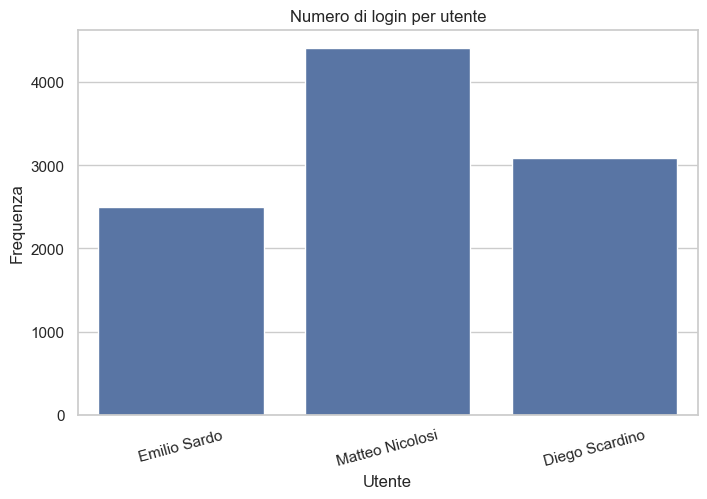

In [99]:
# =========================
# DISTRIBUCIÓN DE LOGINS POR USUARIO
# DISTRIBUZIONE DEI LOGIN PER UTENTE
# =========================

# Creamos una columna temporal con el nombre del usuario
# a partir del identificador numérico.
# Creiamo una colonna temporanea con il nome dell'utente
# a partire dall'identificativo numerico.
login_df["user_name"] = login_df["user_id"].map(user_names)

# Analizamos cuántos registros de login tiene cada usuario.
# Esto permite comprobar si todos los usuarios tienen
# suficiente representación en el dataset.
# Analizziamo quanti record di login ha ogni utente.
# Questo permette di verificare se tutti gli utenti hanno
# una rappresentazione sufficiente nel dataset.
print("Record per utente nel Login Log")
display(login_df["user_name"].value_counts())

# Visualización gráfica del número de logins por usuario.
# Visualizzazione grafica del numero di login per utente.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="user_name")
plt.title("Numero di login per utente")
plt.xlabel("Utente")
plt.ylabel("Frequenza")
plt.xticks(rotation=15)
plt.show()

# explicar graficas

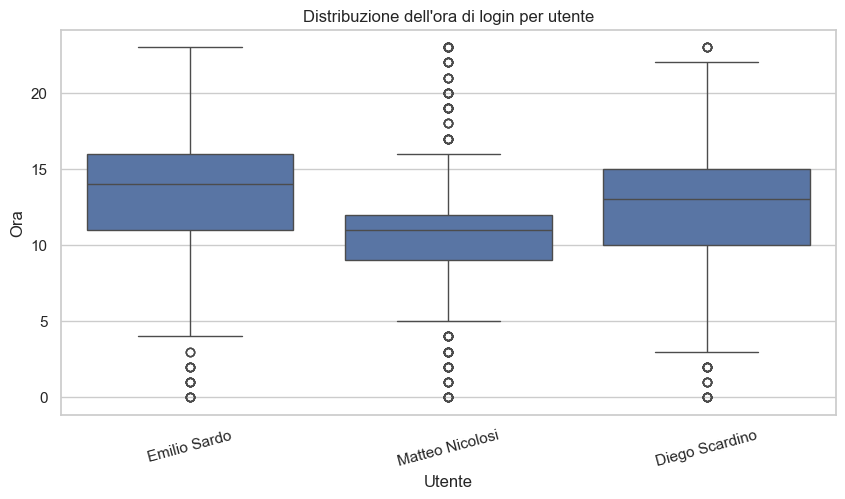

In [100]:
# =========================
# BOXPLOT DE LA HORA DE LOGIN POR USUARIO
# BOXPLOT DELL'ORA DI LOGIN PER UTENTE
# =========================

# El boxplot permite observar la distribución de la hora de login
# para cada usuario y detectar visualmente posibles valores poco frecuentes.
# Il boxplot permette di osservare la distribuzione dell'ora di login
# per ciascun utente e di rilevare visivamente possibili valori poco frequenti.
plt.figure(figsize=(10, 5))
sns.boxplot(data=login_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di login per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()


# explicar grafica

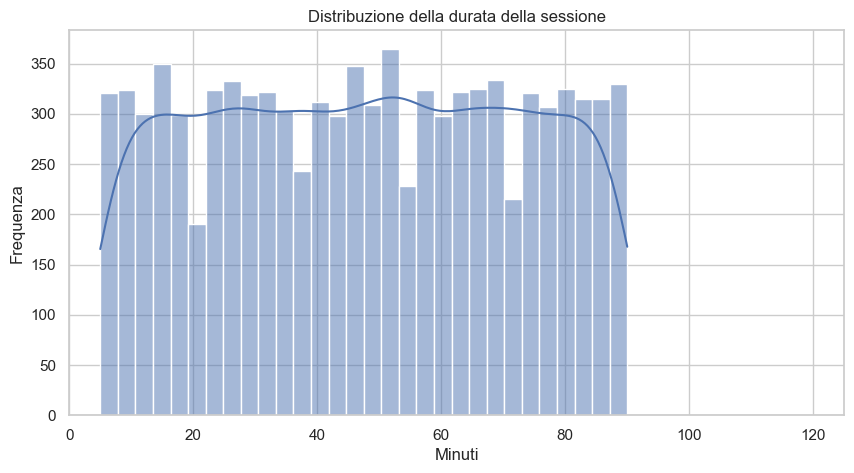

In [101]:
# Histograma de la duración de las sesiones de login.
# Se añade también una curva KDE para visualizar mejor la densidad.
# Istogramma della durata delle sessioni di login.
# Si aggiunge anche una curva KDE per visualizzare meglio la densità.
plt.figure(figsize=(10, 5))
sns.histplot(login_df["session_duration_min"].dropna(), bins=30, kde=True)
plt.title("Distribuzione della durata della sessione")
plt.xlabel("Minuti")
plt.ylabel("Frequenza")
plt.xlim(0, 125)
plt.show()

# Esta gráfica representa la duración de las sesiones abiertas de los usuarios, calculada como la diferencia entre la hora de login y la hora de logout. 
# La curva que aparece superpuesta muestra la densidad de la distribución, es decir, una aproximación suavizada de cómo se reparten las duraciones de las sesiones.
# Questo grafico rappresenta la durata delle sessioni aperte degli utenti, calcolata come differenza tra l’ora di login e l’ora di logout.
# La curva sovrapposta mostra la densità della distribuzione, cioè un’approssimazione smussata di come sono distribuite le durate delle sessioni.

Azioni per utente


user_name        action_name
Diego Scardino   Visualize       780
                 Edit            753
                 Share           747
                 Create          717
                 Copy             18
                 Delete           14
Emilio Sardo     Copy            631
                 Edit            626
                 Visualize       593
                 Share           584
                 Create           12
                 Delete           10
Matteo Nicolosi  Visualize      1537
                 Copy           1478
                 Share          1457
                 Create           16
                 Delete           14
                 Edit             13
Name: count, dtype: int64

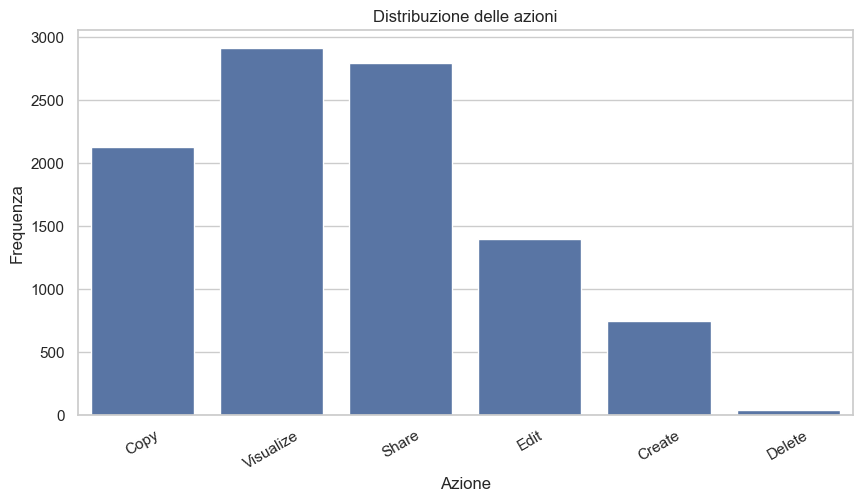

In [102]:
# Mostramos un resumen de cuántas veces realiza cada usuario
# cada tipo de acción.
# Mostriamo un riepilogo di quante volte ogni utente esegue
# ogni tipo di azione.
print("Azioni per utente")
display(activity_df.groupby("user_name")["action_name"].value_counts())

# Gráfico de la distribución global de acciones.
# Grafico della distribuzione globale delle azioni.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="action_name")
plt.title("Distribuzione delle azioni")
plt.xlabel("Azione")
plt.ylabel("Frequenza")
plt.xticks(rotation=30)
plt.show()

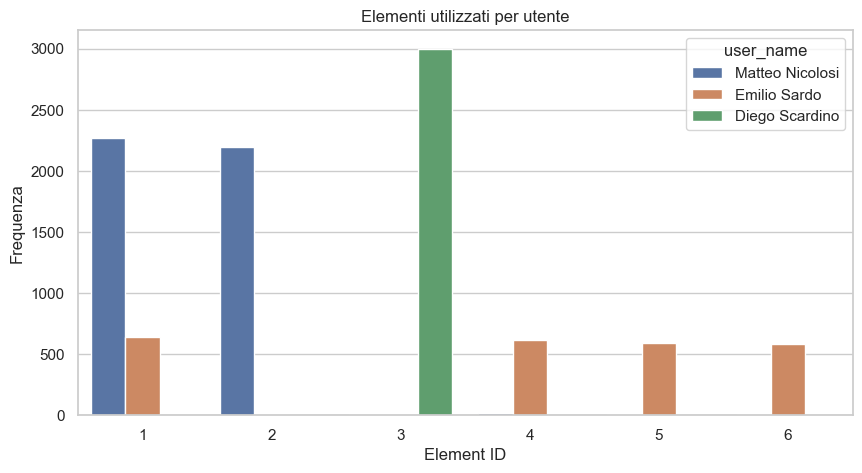

In [103]:
# =========================
# USO DE ELEMENTOS POR USUARIO
# UTILIZZO DEGLI ELEMENTI PER UTENTE
# =========================

# Este gráfico permite ver qué elementos utiliza cada usuario.
# Es útil para observar patrones de acceso y combinaciones habituales.
# Questo grafico permette di vedere quali elementi utilizza ciascun utente.
# È utile per osservare pattern di accesso e combinazioni abituali.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="element_id", hue="user_name")
plt.title("Elementi utilizzati per utente")
plt.xlabel("Element ID")
plt.ylabel("Frequenza")
plt.show()

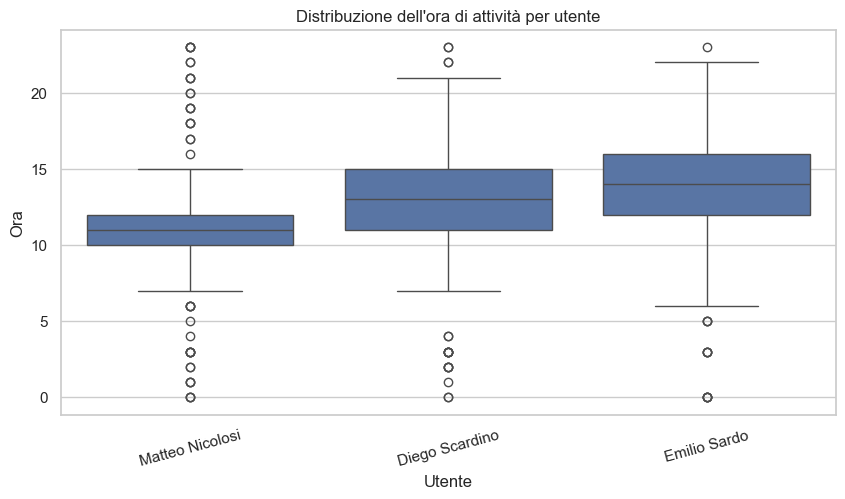

In [104]:
# =========================
# BOXPLOT DE LA HORA DE ACTIVIDAD POR USUARIO
# BOXPLOT DELL'ORA DI ATTIVITÀ PER UTENTE
# =========================

# Este gráfico permite observar la distribución horaria de las actividades
# realizadas por cada usuario.
# Questo grafico permette di osservare la distribuzione oraria delle attività
# svolte da ciascun utente.
plt.figure(figsize=(10, 5))
sns.boxplot(data=activity_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di attività per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()

# Esta gráfica representa la distribución de la hora de actividad de cada usuario. La línea central dentro de cada caja indica la mediana, 
# mientras que la caja azul recoge el 50% central de las actividades. 
# Los bigotes muestran el rango habitual y los puntos blancos representan valores atípicos. 
# Se observa que cada usuario sigue un patrón horario diferente, aunque también aparecen actividades en horas poco frecuentes, 
# que pueden interpretarse como posibles anomalías

# Questo grafico rappresenta la distribuzione dell’ora di attività di ciascun utente. La linea centrale all’interno di ogni scatola indica la mediana, 
# mentre la scatola blu raccoglie il 50% centrale delle attività.
# I baffi mostrano l’intervallo abituale e i punti bianchi rappresentano valori atipici.
# Si osserva che ogni utente segue un pattern orario differente, anche se compaiono anche attività in orari poco frequenti,
#  che possono essere interpretate come possibili anomalie.

In [105]:
# =========================
# PRUEBA MANUAL DE ANOMALÍAS EN ACTIVITY
# TEST MANUALE DELLE ANOMALIE IN ACTIVITY
# =========================

# Esta celda entrena un modelo de detección de anomalías por usuario
# y permite probar manualmente nuevas actividades.
# Questa cella addestra un modello di rilevamento anomalie per utente
# e permette di testare manualmente nuove attività.

from sklearn.ensemble import IsolationForest

# Variables que usaremos para el modelo.
# Variabili che useremo per il modello.
features_activity = ["element_id", "entity_id", "action_id", "hour", "minute", "day_of_week"]

# Preparamos una copia del dataset de actividad.
# Prepariamo una copia del dataset di attività.
activity_model_df = activity_df.copy()

# Nos aseguramos de que las variables temporales existen.
# Ci assicuriamo che le variabili temporali esistano.
activity_model_df["hour"] = activity_model_df["logged_at"].dt.hour
activity_model_df["minute"] = activity_model_df["logged_at"].dt.minute
activity_model_df["day_of_week"] = activity_model_df["logged_at"].dt.dayofweek

# Entrenamos un modelo por usuario.
# Addestriamo un modello per utente.
activity_user_models = {}

for user_id in sorted(activity_model_df["user_id"].unique()):
    user_data = activity_model_df[activity_model_df["user_id"] == user_id].copy()

    if len(user_data) < 10:
        print(f"Utente {user_id}: dati insufficienti per addestrare il modello.")
        continue

    X_user = pd.get_dummies(
        user_data[features_activity],
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42
    )
    model.fit(X_user)

    activity_user_models[user_id] = {
        "model": model,
        "feature_columns": X_user.columns.tolist()
    }

print("Modelli di Activity addestrati correttamente.")


def predict_activity_anomaly(user_id, element_id, entity_id, action_id, logged_at):
    """
    Prueba manualmente una actividad nueva usando el modelo del usuario.

    Devuelve:
    - prediction: 1 si el caso parece anómalo, 0 si parece normal
    - score: puntuación de rareza

    Testa manualmente una nuova attività usando il modello dell'utente.

    Restituisce:
    - prediction: 1 se il caso sembra anomalo, 0 se sembra normale
    - score: punteggio di rarità
    """
    logged_at = pd.to_datetime(logged_at)

    if user_id not in activity_user_models:
        print(f"Nessun modello disponibile per user_id={user_id}")
        return None, None

    row = pd.DataFrame([{
        "element_id": element_id,
        "entity_id": entity_id,
        "action_id": action_id,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek
    }])

    row_encoded = pd.get_dummies(
        row,
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    model_data = activity_user_models[user_id]
    model = model_data["model"]
    feature_columns = model_data["feature_columns"]

    for col in feature_columns:
        if col not in row_encoded.columns:
            row_encoded[col] = 0

    row_encoded = row_encoded[feature_columns]

    raw_prediction = model.predict(row_encoded)[0]   # 1 normal, -1 anomalous
    raw_score = model.decision_function(row_encoded)[0]

    prediction = 1 if raw_prediction == -1 else 0
    score = float(-raw_score)

    print("=== RISULTATO DEL MODELLO ===")
    print("Previsione:", "ANOMALO" if prediction == 1 else "NORMALE")
    print(f"Score di anomalia: {score:.6f}")

    return prediction, score


# Ejemplo de uso:
# Esempio di utilizzo:
predict_activity_anomaly(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000005,
    logged_at="2026-01-20 13:15:00"
)

Modelli di Activity addestrati correttamente.
=== RISULTATO DEL MODELLO ===
Previsione: ANOMALO
Score di anomalia: 0.045216


(1, 0.04521633204820796)

In [106]:
# =========================
# PREPARACIÓN FINAL DEL DATASET PARA MACHINE LEARNING
# PREPARAZIONE FINALE DEL DATASET PER IL MACHINE LEARNING
# =========================

# En este proyecto no utilizamos rules.py para etiquetar anomalías.
# El objetivo es que el modelo aprenda el comportamiento normal
# de cada usuario directamente a partir de los datos históricos.
#
# In questo progetto non utilizziamo rules.py per etichettare le anomalie.
# L'obiettivo è che il modello impari il comportamento normale
# di ciascun utente direttamente a partire dai dati storici.

# Creamos una copia específica del dataset de actividad para modelado.
# Creiamo una copia specifica del dataset di attività per la modellazione.
activity_ml_df = activity_df.copy()

# Seleccionamos las variables que describen el comportamiento del usuario.
# Selezioniamo le variabili che descrivono il comportamento dell'utente.
features_activity = [
    "user_id",
    "element_id",
    "entity_id",
    "action_id",
    "hour",
    "minute",
    "day_of_week"
]

activity_ml_df = activity_ml_df[features_activity].copy()

# Mostramos una vista previa del dataset final que se utilizará
# para entrenar el modelo de detección de anomalías.
# Mostriamo un'anteprima del dataset finale che verrà utilizzato
# per addestrare il modello di rilevamento anomalie.
display(activity_ml_df.head())

print("Shape del dataset per il machine learning:", activity_ml_df.shape)

,user_id,element_id,entity_id,action_id,hour,minute,day_of_week
0,1,2,1,1000004,11,28,1
1,1,2,1,1000000,9,43,3
2,1,2,1,1000000,10,20,3
3,1,1,1,1000005,12,10,1
4,2,3,1,1000000,15,38,0


Shape del dataset per il machine learning: (10000, 7)


In [107]:
# =========================
# ENTRENAMIENTO DEL MODELO DE ANOMALÍAS POR USUARIO
# ADDESTRAMENTO DEL MODELLO DI ANOMALIE PER UTENTE
# =========================

# Utilizamos IsolationForest porque el objetivo no es clasificar
# con reglas fijas, sino detectar comportamientos poco habituales
# respecto al patrón normal de cada usuario.
# Utilizziamo IsolationForest perché l'obiettivo non è classificare
# con regole fisse, ma rilevare comportamenti poco abituali
# rispetto al pattern normale di ciascun utente.

activity_user_models = {}

for user_id in sorted(activity_ml_df["user_id"].unique()):
    # Filtramos solo las actividades del usuario actual.
    # Filtriamo solo le attività dell'utente corrente.
    user_data = activity_ml_df[activity_ml_df["user_id"] == user_id].copy()

    # Comprobamos que haya suficientes registros para entrenar.
    # Verifichiamo che ci siano abbastanza record per addestrare.
    if len(user_data) < 10:
        print(f"Utente {user_id}: dati insufficienti per addestrare il modello.")
        continue

    # Eliminamos user_id de las variables de entrada porque cada modelo
    # se entrena de forma independiente para un solo usuario.
    # Rimuoviamo user_id dalle variabili di input perché ogni modello
    # viene addestrato in modo indipendente per un solo utente.
    X_user = user_data.drop(columns=["user_id"]).copy()

    # Convertimos las variables categóricas en variables dummy.
    # Convertiamo le variabili categoriche in variabili dummy.
    X_user = pd.get_dummies(
        X_user,
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    # Creamos y entrenamos el modelo.
    # Creiamo e addestriamo il modello.
    model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42
    )
    model.fit(X_user)

    # Guardamos el modelo y las columnas usadas en el entrenamiento.
    # Salviamo il modello e le colonne usate durante l'addestramento.
    activity_user_models[user_id] = {
        "model": model,
        "feature_columns": X_user.columns.tolist()
    }

    print(f"Utente {user_id}: modello addestrato con {len(user_data)} record.")

Utente 1: modello addestrato con 4515 record.
Utente 2: modello addestrato con 3029 record.
Utente 3: modello addestrato con 2456 record.


In [108]:
# =========================
# APLICACIÓN DEL MODELO SOBRE TODO EL DATASET
# APPLICAZIONE DEL MODELLO SU TUTTO IL DATASET
# =========================

# Vamos a aplicar el modelo correspondiente a cada usuario
# sobre todas sus actividades para obtener:
# - una predicción de normalidad/anomalía
# - un score de rareza
#
# Applicheremo il modello corrispondente a ciascun utente
# su tutte le sue attività per ottenere:
# - una previsione di normalità/anomalia
# - uno score di rarità

activity_results_df = activity_df.copy()
activity_results_df["ml_prediction"] = np.nan
activity_results_df["anomaly_score"] = np.nan

for user_id in sorted(activity_results_df["user_id"].unique()):
    if user_id not in activity_user_models:
        print(f"Utente {user_id}: nessun modello disponibile.")
        continue

    user_mask = activity_results_df["user_id"] == user_id
    user_data = activity_results_df.loc[user_mask].copy()

    # Preparamos las mismas variables usadas durante el entrenamiento.
    # Prepariamo le stesse variabili usate durante l'addestramento.
    X_user = user_data[[
        "element_id",
        "entity_id",
        "action_id",
        "hour",
        "minute",
        "day_of_week"
    ]].copy()

    X_user = pd.get_dummies(
        X_user,
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    model_data = activity_user_models[user_id]
    model = model_data["model"]
    feature_columns = model_data["feature_columns"]

    # Alineamos las columnas del dataset actual con las columnas
    # exactas usadas en el entrenamiento del modelo.
    # Allineiamo le colonne del dataset attuale con le colonne
    # esatte usate durante l'addestramento del modello.
    for col in feature_columns:
        if col not in X_user.columns:
            X_user[col] = 0

    X_user = X_user[feature_columns]

    # En IsolationForest:
    #  1  = normal
    # -1 = anómalo
    #
    # In IsolationForest:
    #  1  = normale
    # -1 = anomalo
    raw_pred = model.predict(X_user)
    raw_score = model.decision_function(X_user)

    # Convertimos la salida a una codificación más clara:
    # 0 = normal
    # 1 = anómalo
    #
    # Convertiamo l'output in una codifica più chiara:
    # 0 = normale
    # 1 = anomalo
    ml_prediction = np.where(raw_pred == -1, 1, 0)

    # Cuanto más alto sea este valor, más raro parece el caso.
    # Più alto è questo valore, più raro sembra il caso.
    anomaly_score = -raw_score

    activity_results_df.loc[user_mask, "ml_prediction"] = ml_prediction
    activity_results_df.loc[user_mask, "anomaly_score"] = anomaly_score

print("Predizioni generate correttamente.")
display(activity_results_df.head())

Predizioni generate correttamente.


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,entity_name,hour,minute,day_of_week,date,is_weekday,time_block,ml_prediction,anomaly_score
0,243041,1,2,1,1000004,2026-03-24 11:28:39,Matteo Nicolosi,Copy,Password,11,28,1,2026-03-24,1,morning,0.0,-0.039394
1,243042,1,2,1,1000000,2026-03-12 09:43:11,Matteo Nicolosi,Visualize,Password,9,43,3,2026-03-12,1,morning,0.0,-0.014886
2,243043,1,2,1,1000000,2026-03-12 10:20:46,Matteo Nicolosi,Visualize,Password,10,20,3,2026-03-12,1,morning,0.0,-0.027209
3,243044,1,1,1,1000005,2026-04-07 12:10:38,Matteo Nicolosi,Share,Password,12,10,1,2026-04-07,1,afternoon,0.0,-0.041151
4,243045,2,3,1,1000000,2026-03-09 15:38:28,Diego Scardino,Visualize,Password,15,38,0,2026-03-09,1,afternoon,0.0,-0.042334


Distribuzione delle predizioni per utente


ml_prediction,0.0,1.0
user_name,,
Diego Scardino,2877,152
Emilio Sardo,2333,123
Matteo Nicolosi,4291,224


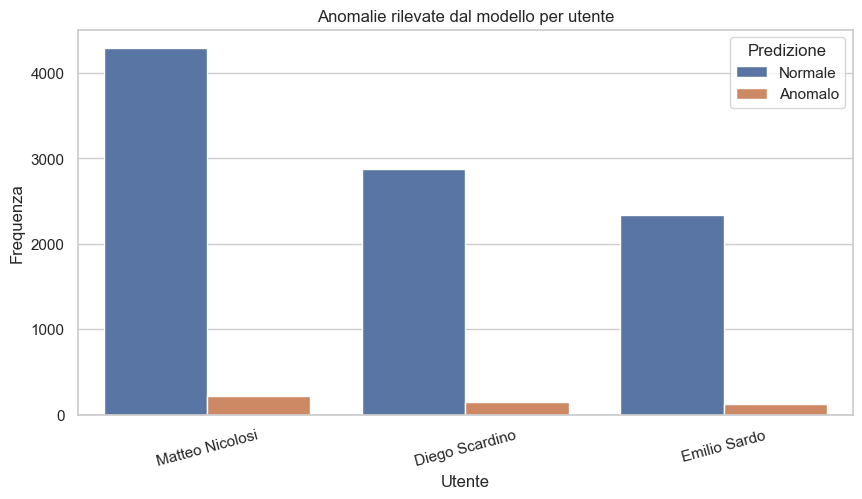

In [109]:
# =========================
# RESUMEN DE ANOMALÍAS DETECTADAS POR USUARIO
# RIEPILOGO DELLE ANOMALIE RILEVATE PER UTENTE
# =========================

# Creamos una columna con el nombre del usuario para que la lectura
# de los resultados sea más clara.
# Creiamo una colonna con il nome dell'utente per rendere più chiara
# la lettura dei risultati.
user_names = {
    1: "Matteo Nicolosi",
    2: "Diego Scardino",
    3: "Emilio Sardo"
}

activity_results_df["user_name"] = activity_results_df["user_id"].map(user_names)

# Mostramos cuántas actividades ha marcado el modelo como normales
# y cuántas como anómalas para cada usuario.
# Mostriamo quante attività il modello ha segnato come normali
# e quante come anomale per ciascun utente.
print("Distribuzione delle predizioni per utente")
display(
    activity_results_df.groupby("user_name")["ml_prediction"].value_counts().unstack(fill_value=0)
)

# Visualización gráfica de las anomalías detectadas por usuario.
# Visualizzazione grafica delle anomalie rilevate per utente.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_results_df, x="user_name", hue="ml_prediction")
plt.title("Anomalie rilevate dal modello per utente")
plt.xlabel("Utente")
plt.ylabel("Frequenza")
plt.xticks(rotation=15)
plt.legend(title="Predizione", labels=["Normale", "Anomalo"])
plt.show()

In [110]:
# =========================
# CASOS ANÓMALOS DETECTADOS POR EL MODELO
# CASI ANOMALI RILEVATI DAL MODELLO
# =========================

# Filtramos únicamente las actividades que el modelo ha marcado como anómalas.
# Filtriamo unicamente le attività che il modello ha contrassegnato come anomale.
activity_anomalies_detected = activity_results_df[activity_results_df["ml_prediction"] == 1].copy()

# Ordenamos los casos por score de anomalía de mayor a menor.
# In questo modo vediamo primero los casos más raros.
# Ordiniamo i casi per score di anomalia dal più alto al più basso.
# In questo modo vediamo prima i casi più rari.
activity_anomalies_detected = activity_anomalies_detected.sort_values(
    by="anomaly_score",
    ascending=False
)

print("Numero totale di anomalie rilevate:", activity_anomalies_detected.shape[0])

# Mostramos los casos más anómalos detectados por el modelo.
# Mostriamo i casi più anomali rilevati dal modello.
display(
    activity_anomalies_detected[
        [
            "activity_log_id",
            "user_id",
            "user_name",
            "element_id",
            "entity_id",
            "action_id",
            "hour",
            "minute",
            "day_of_week",
            "logged_at",
            "anomaly_score"
        ]
    ].head(20)
)

Numero totale di anomalie rilevate: 499


,activity_log_id,user_id,user_name,element_id,entity_id,action_id,hour,minute,day_of_week,logged_at,anomaly_score
7540,250581,1,Matteo Nicolosi,2,3,1000005,13,1,3,2026-01-08 13:01:24,0.112596
1148,244189,1,Matteo Nicolosi,2,3,1000000,15,27,6,2025-12-28 15:27:58,0.111012
8450,251491,1,Matteo Nicolosi,1,3,1000004,0,52,2,2026-01-28 00:52:29,0.107978
1543,244584,1,Matteo Nicolosi,1,3,1000005,13,4,3,2026-01-01 13:04:50,0.107025
6159,249200,1,Matteo Nicolosi,2,2,1000005,10,55,1,2026-03-03 10:55:33,0.105803
4020,247061,1,Matteo Nicolosi,1,3,1000004,13,1,0,2025-12-29 13:01:38,0.103992
7456,250497,1,Matteo Nicolosi,1,2,1000005,9,3,4,2026-03-27 09:03:06,0.097431
9493,252534,1,Matteo Nicolosi,2,2,1000005,9,39,4,2025-12-26 09:39:21,0.096210
487,243528,1,Matteo Nicolosi,1,3,1000004,11,0,4,2026-03-27 11:00:47,0.095784
4732,247773,1,Matteo Nicolosi,2,3,1000000,11,0,3,2026-01-29 11:00:46,0.094625


In [111]:
# =========================
# PRUEBA MANUAL DE UNA NUEVA ACTIVIDAD
# TEST MANUALE DI UNA NUOVA ATTIVITÀ
# =========================

def predict_new_activity(user_id, element_id, entity_id, action_id, logged_at):
    """
    Prueba manualmente una nueva actividad con el modelo del usuario.

    Devuelve:
    - prediction: 0 si parece normal, 1 si parece anómala
    - anomaly_score: cuanto mayor sea, más raro parece el caso

    Testa manualmente una nuova attività con il modello dell'utente.

    Restituisce:
    - prediction: 0 se sembra normale, 1 se sembra anomala
    - anomaly_score: più è alto, più raro sembra il caso
    """
    logged_at = pd.to_datetime(logged_at)

    if user_id not in activity_user_models:
        print(f"Nessun modello disponibile per user_id={user_id}")
        return None, None

    # Construimos la fila con la misma estructura lógica usada en el entrenamiento.
    # Costruiamo la riga con la stessa struttura logica usata durante l'addestramento.
    row = pd.DataFrame([{
        "element_id": element_id,
        "entity_id": entity_id,
        "action_id": action_id,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek
    }])

    # Aplicamos el mismo proceso de codificación.
    # Applichiamo lo stesso processo di codifica.
    row_encoded = pd.get_dummies(
        row,
        columns=["element_id", "entity_id", "action_id", "day_of_week"],
        dtype=int
    )

    model_data = activity_user_models[user_id]
    model = model_data["model"]
    feature_columns = model_data["feature_columns"]

    # Alineamos las columnas con las del entrenamiento.
    # Allineiamo le colonne con quelle del training.
    for col in feature_columns:
        if col not in row_encoded.columns:
            row_encoded[col] = 0

    row_encoded = row_encoded[feature_columns]

    raw_pred = model.predict(row_encoded)[0]
    raw_score = model.decision_function(row_encoded)[0]

    prediction = 1 if raw_pred == -1 else 0
    anomaly_score = float(-raw_score)

    print("=== RISULTATO DEL MODELLO ===")
    print("Previsione:", "ANOMALO" if prediction == 1 else "NORMALE")
    print(f"Score di anomalia: {anomaly_score:.6f}")

    return prediction, anomaly_score


# Ejemplo de uso:
# Esempio di utilizzo:
predict_new_activity(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000005,
    logged_at="2026-01-20 13:15:00"
)

=== RISULTATO DEL MODELLO ===
Previsione: ANOMALO
Score di anomalia: 0.045216


(1, 0.04521633204820796)

In [112]:
activity_results_df["ml_prediction"].value_counts()

ml_prediction
0.0    9501
1.0     499
Name: count, dtype: int64

In [113]:
activity_results_df["anomaly_score"].describe()

count    10000.000000
mean        -0.024817
std          0.017566
min         -0.058691
25%         -0.036381
50%         -0.026728
75%         -0.017142
max          0.112596
Name: anomaly_score, dtype: float64

In [114]:
predict_new_activity(
    user_id=1,
    element_id=1,
    entity_id=1,
    action_id=1000000,
    logged_at="2026-04-16 10:30:00"
)

=== RISULTATO DEL MODELLO ===
Previsione: NORMALE
Score di anomalia: -0.039249


(0, -0.03924930616005362)

In [115]:
predict_new_activity(
    user_id=1,
    element_id=5,
    entity_id=3,
    action_id=1000003,
    logged_at="2026-04-16 02:15:00"
)

=== RISULTATO DEL MODELLO ===
Previsione: ANOMALO
Score di anomalia: 0.164340


(1, 0.16433954602861212)

In [116]:
predict_new_activity(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000005,
    logged_at="2026-04-16 16:20:00"
)

=== RISULTATO DEL MODELLO ===
Previsione: ANOMALO
Score di anomalia: 0.061258


(1, 0.06125751227857679)

In [121]:
predict_new_activity(
    user_id=1,
    element_id=1,
    entity_id=1,
    action_id=1000000,
    logged_at='2026-04-14 11:00:30'
)

=== RISULTATO DEL MODELLO ===
Previsione: NORMALE
Score di anomalia: -0.017900


(0, -0.017900299827948052)

# CONCLUSIONES FINALES

A lo largo de este proyecto se han cargado, analizado y preparado dos fuentes principales de datos, **Login Log** y **Activity Log**, con el objetivo de construir una primera **PoC de detección de anomalías** en el comportamiento de los usuarios. Para ello, se han transformado las variables temporales más relevantes, generando información útil como la **hora**, el **minuto**, el **día de la semana** y la **duración de la sesión**, lo que ha permitido enriquecer el análisis y preparar correctamente los datos para el modelado.

Uno de los avances más importantes del proyecto ha sido la **integración directa del notebook con la base de datos PostgreSQL y con el archivo `rules.py`**, de forma que tanto el análisis exploratorio como el etiquetado de anomalías y el entrenamiento de modelos utilicen siempre la misma lógica de negocio definida en el sistema. Esto ha permitido evitar inconsistencias entre el notebook, la aplicación de login y el modelo de machine learning, manteniendo un flujo de trabajo unificado y coherente.

A partir de las reglas de negocio definidas, se han implementado criterios de detección para identificar comportamientos anómalos, tales como **logins fuera de la franja horaria habitual del usuario**, accesos realizados **fuera de los días laborables**, actividades ejecutadas **fuera del horario permitido**, accesos a **elementos no autorizados**, acciones sobre **entidades no permitidas** y eventos realizados **fuera del flujo estándar esperado**. De esta manera, se ha construido una base sólida para etiquetar anomalías de forma coherente con el contexto funcional del sistema.

Además, se ha desarrollado un proceso de **generación sintética de datos** para poblar la base de datos con registros de `login_log` y `activity_log` realistas, ajustando progresivamente la proporción de casos normales y anómalos. Este proceso ha requerido varias iteraciones, ya que en un primer momento el porcentaje de anomalías era excesivamente alto y poco realista. Tras revisar tanto las reglas como el generador de datos, se ha conseguido una distribución mucho más coherente, situando el porcentaje de anomalías en torno a un valor razonable para el problema, lo que ha permitido entrenar y evaluar los modelos de forma más consistente.

Sobre esta base, se han entrenado modelos de **Árbol de Decisión** para los datos de login y de actividad, ya que se trata de un enfoque especialmente adecuado para una primera PoC gracias a su **alta interpretabilidad**, su capacidad para **explicar la lógica de clasificación** y su utilidad para presentar resultados de forma clara y defendible ante negocio. Como mejora adicional, se ha incorporado también **Random Forest**, con el fin de reforzar la robustez del sistema. Este modelo ha permitido aportar **mayor estabilidad frente a variaciones del dataset**, **reducir el riesgo de sobreajuste**, **mejorar la capacidad de generalización** en datos no vistos y analizar la relevancia de las variables mediante sus importancias.

Es importante destacar que en este proyecto el **machine learning no sustituye a las reglas de negocio**, sino que las **complementa**. Las reglas permiten detectar anomalías explícitas y conocidas de antemano, mientras que el modelo aporta una segunda capa de análisis capaz de identificar patrones de comportamiento poco habituales o combinaciones sospechosas que no siempre serían fáciles de definir manualmente. De este modo, el sistema combina una capa determinista basada en reglas con una capa predictiva orientada al aprendizaje del comportamiento.

En conjunto, puede concluirse que el **Árbol de Decisión** representa el modelo más adecuado para explicar el comportamiento del sistema y la lógica de negocio, mientras que **Random Forest** constituye una evolución natural del mismo cuando se busca una solución más robusta y orientada a un futuro escenario de producción. Por tanto, el enfoque desarrollado resulta apropiado para una primera fase del proyecto, al combinar **reglas de negocio**, **modelos interpretables**, **datos sintéticos coherentes con el dominio** y una primera mejora orientada a la **robustez predictiva**.

Como líneas de mejora futura, sería recomendable **ampliar el número de usuarios y casuísticas reales**, incorporar **secuencias completas de comportamiento** como `login -> actividad -> logout`, introducir **features agregadas por usuario y por día**, utilizar **datos reales validados por negocio** y evolucionar hacia un **sistema en tiempo real** capaz de bloquear o revisar acciones sospechosas automáticamente. Todo ello permitiría aumentar progresivamente la precisión, la capacidad de detección y la utilidad operativa del sistema en un entorno real.

---

# CONCLUSIONI FINALI

Nel corso di questo progetto sono state caricate, analizzate e preparate due principali fonti di dati, **Login Log** e **Activity Log**, con l’obiettivo di costruire una prima **PoC per il rilevamento delle anomalie** nel comportamento degli utenti. A tal fine, sono state trasformate le variabili temporali più rilevanti, generando informazioni utili come **ora**, **minuto**, **giorno della settimana** e **durata della sessione**, così da arricchire l’analisi e preparare correttamente i dati per il modellamento.

Uno degli avanzamenti più importanti del progetto è stata l’**integrazione diretta del notebook con il database PostgreSQL e con il file `rules.py`**, in modo che sia l’analisi esplorativa sia l’etichettatura delle anomalie e l’addestramento dei modelli utilizzino sempre la stessa logica di business definita nel sistema. Questo ha permesso di evitare incoerenze tra il notebook, l’applicazione di login e il modello di machine learning, mantenendo un flusso di lavoro unificato e coerente.

A partire dalle regole di business definite, sono stati implementati criteri di rilevamento per identificare comportamenti anomali, come **login fuori dalla fascia oraria abituale dell’utente**, accessi effettuati **al di fuori dei giorni lavorativi**, attività eseguite **fuori dall’orario consentito**, accessi a **elementi non autorizzati**, azioni su **entità non consentite** ed eventi effettuati **al di fuori del flusso standard previsto**. In questo modo è stata costruita una base solida per etichettare le anomalie in modo coerente con il contesto funzionale del sistema.

Inoltre, è stato sviluppato un processo di **generazione sintetica dei dati** per popolare il database con record realistici di `login_log` e `activity_log`, regolando progressivamente la proporzione tra casi normali e anomali. Questo processo ha richiesto varie iterazioni, poiché inizialmente la percentuale di anomalie risultava eccessivamente alta e poco realistica. Dopo aver rivisto sia le regole sia il generatore di dati, si è ottenuta una distribuzione molto più coerente, portando la percentuale di anomalie a un valore ragionevole per il problema e consentendo così di addestrare e valutare i modelli in modo più consistente.

Su questa base, sono stati addestrati modelli di **Albero di Decisione** per i dati di login e di activity, poiché si tratta di un approccio particolarmente adatto a una prima PoC grazie alla sua **elevata interpretabilità**, alla capacità di **spiegare chiaramente la logica di classificazione** e alla sua utilità nel presentare risultati in modo comprensibile e difendibile dal punto di vista del business. Come miglioramento aggiuntivo, è stato inoltre introdotto **Random Forest**, con l’obiettivo di rafforzare la robustezza del sistema. Questo modello ha permesso di ottenere **maggiore stabilità rispetto alle variazioni del dataset**, **minore rischio di overfitting**, **migliore capacità di generalizzazione** su dati non visti e la possibilità di analizzare la rilevanza delle variabili attraverso le rispettive importanze.

È importante sottolineare che in questo progetto il **machine learning non sostituisce le regole di business**, ma le **completa**. Le regole permettono di rilevare anomalie esplicite e note in anticipo, mentre il modello aggiunge un secondo livello di analisi capace di identificare pattern di comportamento poco abituali o combinazioni sospette che non sempre sarebbero facili da definire manualmente. In questo modo il sistema combina un livello deterministico basato su regole con un livello predittivo orientato all’apprendimento del comportamento.

Nel complesso, si può concludere che l’**Albero di Decisione** rappresenta il modello più adatto per spiegare il comportamento del sistema e la logica di business, mentre **Random Forest** costituisce una sua naturale evoluzione quando si desidera una soluzione più robusta e orientata a un futuro scenario di produzione. Di conseguenza, l’approccio sviluppato risulta appropriato per una prima fase del progetto, in quanto combina **regole di business**, **modelli interpretabili**, **dati sintetici coerenti con il dominio** e un primo miglioramento orientato alla **robustezza predittiva**.

Come possibili sviluppi futuri, sarebbe consigliabile **ampliare il numero di utenti e di casistiche reali**, includere **sequenze complete di comportamento** come `login -> attività -> logout`, introdurre **feature aggregate per utente e per giorno**, utilizzare **dati reali validati dal business** ed evolvere verso un **sistema in tempo reale** capace di bloccare o sottoporre a revisione automatica le azioni sospette. Tutto ciò permetterebbe di aumentare progressivamente la precisione, la capacità di rilevamento e l’utilità operativa del sistema in un contesto reale.

En este proyecto, el machine learning se usa para complementar las reglas, no para sustituirlas.

Las reglas detectan anomalías obvias porque están definidas previamente.
El machine learning sirve para aprender patrones de comportamiento y detectar casos raros que no están escritos explícitamente en una regla.